# Cultural Evolution: Unbiased and Biased Transmission

**Methods:** Agent-based model of trait transmission; drift vs. selection; finite-size effects; Matplotlib

### Overview
This notebook examines how population size and transmission-bias parameters affect the cultural-evolution ABM.

---

#### Unbiased and Biased transmission model for `n = 100`

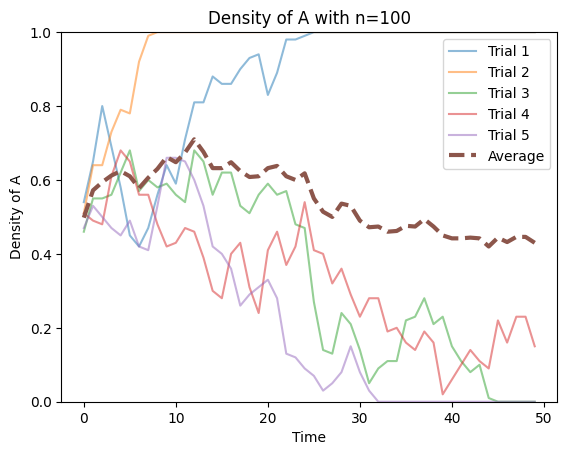

In [ ]:
"""
Cultural evolution ABM unbiased/biased transmission.
Based on course-provided starter code, modified 
for testing various population sizes and 
multi-trial averaging and (sa, sb) parameter.
"""

import random
import matplotlib.pyplot as plt

n = 100 # population size
#n = 10000 # population size 2nd case
sa = 1 # prob of imitating A
sb = 1 # prob of imitating B
P0 = 0.5 # initial density of players with cultural trait A
laststep = 50

all_densityA = []  # store densityA from each iteration

for trial in range(5):

  agent = [1 for i in range(0, n)] # 0=>A, 1=>B
  newagent = [None for i in range(0, n)] # 0=>A, 1=>B

  densityA = [None for i in range(0, laststep)]
  time = [None for i in range(0, laststep)]
  time[0] = 0

  P = 0
  for i in range(0, n):
    if (P0 > random.random()):
      agent[i] = 0 # player with A
      P = P + 1

  densityA[0] = P / n

  for t in range(1, laststep):
    newagent = agent
    #print('time=', t, 'agent')
    #print(agent)
    #print('time=', t, 'newagent')
    #print(newagent)

    for i in range(0, n):
      demo = random.randrange(0, n)
      if agent[demo] == 0: # A
        if sa > random.random():
          newagent[i] = 0
      elif agent[demo] == 1: # B
        if sb > random.random():
          newagent[i] = 1

    #print('time=', t, 'newagent renewed')
    #print(newagent)
    agent = newagent

    P = 0
    for i in range(0, n):
      if agent[i] == 0:
        P = P + 1

    densityA[t] = P / n
    time[t] = t

  all_densityA.append(densityA)

# compute average over 5 iterations
average_densityA = []
for t in range(0, laststep):
  s = 0
  for trial in range(5):
    s += all_densityA[trial][t]
  average_densityA.append(s / 5)

# plot individual trials
for trial in range(5):
  plt.plot(time, all_densityA[trial], alpha=0.5, label=f"Trial {trial+1}")

# plot average
plt.plot(time, average_densityA, linewidth=3, linestyle='--', label="Average")

plt.ylim(0, 1)
plt.xlabel("Time")
plt.ylabel("Density of A")
plt.title(f"Density of A with n={n}")
plt.legend()
# plt.savefig('unbiased_biased_5trials_avg.png')
plt.show()

The above graph is modified to match the requirement of 5 simulations and then plot the average result of the case `n = 100`.

### Unbiased and Biased transmission model for `n = 10000`

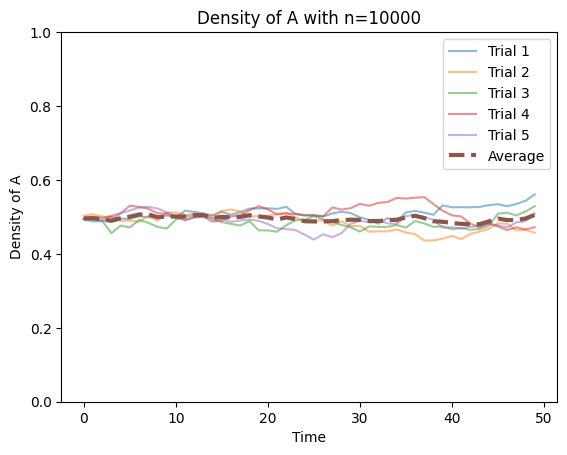

In [ ]:
"""
Cultural evolution ABM unbiased/biased transmission.
Based on course-provided starter code, modified 
for testing various population sizes and 
multi-trial averaging and (sa, sb) parameter.
"""

import random
import matplotlib.pyplot as plt

#n = 100 # population size
n = 10000 # population size 2nd case
sa = 1 # prob of imitating A
sb = 1 # prob of imitating B
P0 = 0.5 # initial density of players with cultural trait A
laststep = 50

all_densityA = []  # store densityA from each iteration

for trial in range(5):

  agent = [1 for i in range(0, n)] # 0=>A, 1=>B
  newagent = [None for i in range(0, n)] # 0=>A, 1=>B

  densityA = [None for i in range(0, laststep)]
  time = [None for i in range(0, laststep)]
  time[0] = 0

  P = 0
  for i in range(0, n):
    if (P0 > random.random()):
      agent[i] = 0 # player with A
      P = P + 1

  densityA[0] = P / n

  for t in range(1, laststep):
    newagent = agent
    #print('time=', t, 'agent')
    #print(agent)
    #print('time=', t, 'newagent')
    #print(newagent)

    for i in range(0, n):
      demo = random.randrange(0, n)
      if agent[demo] == 0: # A
        if sa > random.random():
          newagent[i] = 0
      elif agent[demo] == 1: # B
        if sb > random.random():
          newagent[i] = 1

    #print('time=', t, 'newagent renewed')
    #print(newagent)
    agent = newagent

    P = 0
    for i in range(0, n):
      if agent[i] == 0:
        P = P + 1

    densityA[t] = P / n
    time[t] = t

  all_densityA.append(densityA)

# compute average over 5 iterations
average_densityA = []
for t in range(0, laststep):
  s = 0
  for trial in range(5):
    s += all_densityA[trial][t]
  average_densityA.append(s / 5)

# plot individual trials
for trial in range(5):
  plt.plot(time, all_densityA[trial], alpha=0.5, label=f"Trial {trial+1}")

# plot average
plt.plot(time, average_densityA, linewidth=3, linestyle='--', label="Average")

plt.ylim(0, 1)
plt.xlabel("Time")
plt.ylabel("Density of A")
plt.title(f"Density of A with n={n}")
plt.legend()
# plt.savefig('unbiased_biased_5trials_avg.png')
plt.show()

The above graph is modified to match the requirement of 5 simulations and then plot the average result of the case `n = 10000`.

### Comparing the result
we can see that when `n = 100` random sampling effects are strong: even under unbiased transmission ($s_a = s_b$), the system frequently drifts toward either trait A or B. And the long-run outcome is highly path-dependent. Averaging across iterations decrease these fluctuations but doesn't remove the fact that this case of `n = 100` is underlying tendency toward random fixation.

However, when `n = 10000`, this randomness fluctuations is significantly reduced, which make the graph trajectories are smoother, fixation is slower, and the system remains closer to its initial condition.

---

### Running simulation on various $s_a$ and $s_b$ cases

where `n = 10000`


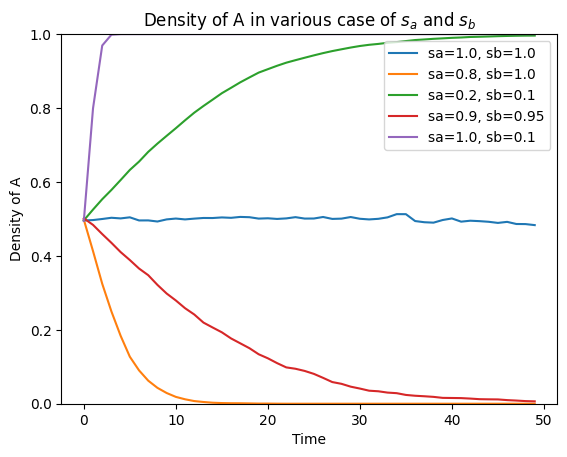

In [ ]:
"""
Cultural evolution ABM unbiased/biased transmission.
Based on course-provided starter code, modified 
for testing various population sizes and 
multi-trial averaging and (sa, sb) parameter.
"""

import random
import matplotlib.pyplot as plt

#n = 100 # population size
n = 10000 # population size 2nd case
P0 = 0.5 # initial density of players with cultural trait A
laststep = 50

# 5 cases of (sa, sb)
sa_sb_cases = [
  (1.0, 1.0),
  (0.8, 1.0),
  (0.2, 0.1),
  (0.9, 0.95),
  (1.0, 0.1)
]

for case in sa_sb_cases:

  sa, sb = case  # prob of imitating A, B

  all_densityA = []  # store densityA from each iteration

  for trial in range(5):

    agent = [1 for i in range(0, n)] # 0=>A, 1=>B
    newagent = [None for i in range(0, n)] # 0=>A, 1=>B

    densityA = [None for i in range(0, laststep)]
    time = [None for i in range(0, laststep)]
    time[0] = 0

    P = 0
    for i in range(0, n):
      if (P0 > random.random()):
        agent[i] = 0 # player with A
        P = P + 1

    densityA[0] = P / n

    for t in range(1, laststep):
      newagent = agent
      #print('time=', t, 'agent')
      #print(agent)
      #print('time=', t, 'newagent')
      #print(newagent)

      for i in range(0, n):
        demo = random.randrange(0, n)
        if agent[demo] == 0: # A
          if sa > random.random():
            newagent[i] = 0
        elif agent[demo] == 1: # B
          if sb > random.random():
            newagent[i] = 1

      #print('time=', t, 'newagent renewed')
      #print(newagent)
      agent = newagent

      P = 0
      for i in range(0, n):
        if agent[i] == 0:
          P = P + 1

      densityA[t] = P / n
      time[t] = t

    all_densityA.append(densityA)

  # compute average over 5 iterations
  average_densityA = []
  for t in range(0, laststep):
    s = 0
    for trial in range(5):
      s += all_densityA[trial][t]
    average_densityA.append(s / 5)

  # plot averaged result for this (sa, sb) case
  plt.plot(time, average_densityA, label=f"sa={sa}, sb={sb}")

plt.ylim(0, 1)
plt.xlabel("Time")
plt.ylabel("Density of A")
plt.title("Density of A in various case of $s_a$ and $s_b$")
plt.legend()
# plt.savefig('unbiased_biased_5cases_avg.png')
plt.show()

---

### Discuss the result of various cases of $s_a$ and $s_b$

From Exercise (1) we learned that the case of `n = 100` is relying too much on randomness, hence, selecting to choose `n = 10000` for comparing others biased cases with unbiased case.

When $s_a = s_b$, transmission is unbiased, and no cultural trait has any advantage. Any long-term dominance of A or B solely from randomness fluctuations.

However, when $s_a \neq s_b$, the symmetry is broken. The trait with the higher transmission probability is more likely to be copied, producing a directional force in cultural dynamics; even a slight difference between them (from the graph the case of `sa, sb = (0.9, 0.95)`) break the symmetry.